In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science"])

SCIENCE_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ABLATION_COLOR = SCIENCE_COLORS[1]  # second color in science cycle (green)
OURS_COLOR = SCIENCE_COLORS[2]  # third color in science cycle (orange)

ablation_data = pd.read_csv("expdata/ablation_q_robot.csv")
base_data = pd.read_csv("expdata/robot_calfq.csv")
base_baseline_calls = pd.read_csv("expdata/baselinepolicy_fraction_robot.csv")


def select_metrics(data, metric_name):
    return data[data["key"] == metric_name]


In [56]:
def rolling_stats(df, rolling_window=20, grid_step=1000):
    df = df.sort_values(["run_id", "step"])
    df["roll"] = df.groupby("run_id")["value"].transform(
        lambda s: s.rolling(rolling_window, min_periods=1).mean()
    )

    grid = np.arange(df["step"].min(), df["step"].max() + 1, grid_step)
    grid_df = pd.DataFrame({"step": grid}).sort_values("step")

    def ffill_to_grid(run_id, g):
        g = g.sort_values("step")[["step", "roll"]]
        out = pd.merge_asof(grid_df, g, on="step", direction="backward")
        out["run_id"] = run_id
        return out

    interp = pd.concat(
        [ffill_to_grid(run_id, g) for run_id, g in df.groupby("run_id")],
        ignore_index=True,
    )

    mean_by_step = interp.groupby("step")["roll"].mean()
    std_by_step = interp.groupby("step")["roll"].std()
    return mean_by_step, std_by_step


def baseline_policy_band(
    df,
    key="episode_stats/n_safe_actions",
    grid_step=1000,
    grid_start=50_000,
    rolling_window=5,
):
    df = df[df["key"] == key].copy()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["value"]).sort_values(["run_id", "step"])

    grid_begin = max(grid_start, int(df["step"].min()))
    grid = np.arange(grid_begin, df["step"].max() + 1, grid_step)
    grid_df = pd.DataFrame({"step": grid}).sort_values("step")

    def ffill_to_grid(run_id, g):
        g = g.sort_values("step")[["step", "value"]]
        out = pd.merge_asof(grid_df, g, on="step", direction="backward")
        out["run_id"] = run_id
        return out

    interp = pd.concat(
        [ffill_to_grid(run_id, g) for run_id, g in df.groupby("run_id")],
        ignore_index=True,
    )

    means = (
        interp.groupby("step")["value"]
        .mean()
        .rolling(window=rolling_window, min_periods=1)
        .mean()
    )
    stds = (
        interp.groupby("step")["value"]
        .std()
        .rolling(window=rolling_window, min_periods=1)
        .mean()
    )
    return means * 100, stds * 100


<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3036294/1494144015.py:9: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(abl_mean.index, abl_mean, label="Ours (w/o $Q_t^{\dagger}$ tracking)", color=ABLATION_COLOR)


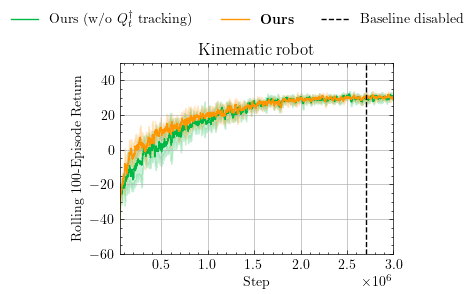

In [57]:
episodic_return_base = select_metrics(base_data, "charts/episodic_return")
episodic_return_ablation = select_metrics(ablation_data, "charts/episodic_return")

base_mean, base_std = rolling_stats(episodic_return_base.copy(), 100, 1000)
abl_mean, abl_std = rolling_stats(episodic_return_ablation.copy(), 100, 1000)

fig, ax = plt.subplots(1, 1, figsize=(3.6, 3.0))

ax.plot(abl_mean.index, abl_mean, label="Ours (w/o $Q_t^{\dagger}$ tracking)", color=ABLATION_COLOR)
ax.fill_between(
    abl_mean.index, abl_mean - abl_std, abl_mean + abl_std, alpha=0.2, color=ABLATION_COLOR
)
ax.plot(base_mean.index, base_mean, label=r"\textbf{Ours}", color=OURS_COLOR)
ax.fill_between(
    base_mean.index, base_mean - base_std, base_mean + base_std, alpha=0.2, color=OURS_COLOR
)

ax.axvline(x=0.9 * 3_000_000, color="black", linestyle="--", label="Baseline disabled")
ax.set_xlim(50_000, 3_000_000)
ax.set_ylim(-60, 50)
ax.set_title("Kinematic robot")
ax.set_xlabel("Step")
ax.set_ylabel("Rolling 100-Episode Return")
ax.grid()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig("../gfx/ablation_episode_return_robot.pdf")


<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3036294/3786599718.py:6: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(abl_calls_mean.index, abl_calls_mean, label="Ours (w/o $Q_t^{\dagger}$ tracking)", color=ABLATION_COLOR)


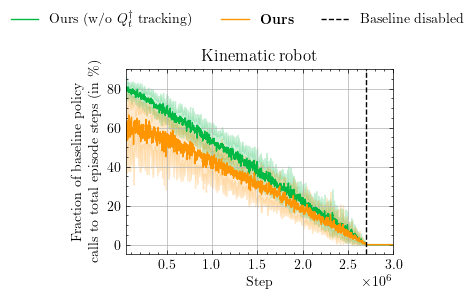

In [58]:
base_calls_mean, base_calls_std = baseline_policy_band(base_baseline_calls)
abl_calls_mean, abl_calls_std = baseline_policy_band(ablation_data)

fig, ax = plt.subplots(1, 1, figsize=(3.6, 3.0))

ax.plot(abl_calls_mean.index, abl_calls_mean, label="Ours (w/o $Q_t^{\dagger}$ tracking)", color=ABLATION_COLOR)
ax.fill_between(
    abl_calls_mean.index,
    abl_calls_mean - abl_calls_std,
    abl_calls_mean + abl_calls_std,
    alpha=0.2,
    color=ABLATION_COLOR,
)
ax.plot(base_calls_mean.index, base_calls_mean, label=r"\textbf{Ours}", color=OURS_COLOR)
ax.fill_between(
    base_calls_mean.index,
    base_calls_mean - base_calls_std,
    base_calls_mean + base_calls_std,
    alpha=0.2,
    color=OURS_COLOR,
)
ax.axvline(x=0.9 * 3_000_000, color="black", linestyle="--", label="Baseline disabled")
ax.set_xlim(50_000, 3_000_000)
ax.set_title("Kinematic robot")
ax.set_xlabel("Step")
ax.set_ylabel(
    r"Fraction of baseline policy \\calls to total episode steps (in \%)"
)
ax.grid()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=[0, 0, 1, 0.9])
fig.savefig("../gfx/ablation_baseline_calls_robot.pdf")


In [59]:
def print_metric_rate(df, label):
    df = df.copy()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["value"])
    df = df[df["step"] >= 2_700_000]
    if df.empty:
        print(label)
        print("no data after 2.7M steps")
        return
    per_run = df.groupby("run_id")["value"].mean()
    print(label)
    print(per_run.mean(), "+-", per_run.std())


def print_combined_rate(goal_df, target_df, label):
    goal_df = goal_df.copy()
    target_df = target_df.copy()
    goal_df["value"] = pd.to_numeric(goal_df["value"], errors="coerce")
    target_df["value"] = pd.to_numeric(target_df["value"], errors="coerce")
    goal_df = goal_df.dropna(subset=["value"])
    target_df = target_df.dropna(subset=["value"])
    goal_df = goal_df[goal_df["step"] >= 2_700_000]
    target_df = target_df[target_df["step"] >= 2_700_000]
    if goal_df.empty or target_df.empty:
        print(label)
        print("no data after 2.7M steps")
        return
    goal_per_run = goal_df.groupby("run_id")["value"].mean()
    target_per_run = target_df.groupby("run_id")["value"].mean()
    aligned = (goal_per_run + target_per_run) / 2
    aligned = aligned.dropna()
    if aligned.empty:
        print(label)
        print("no aligned runs after 2.7M steps")
        return
    print(label)
    print(aligned.mean(), "+-", aligned.std())


def metrics_or_empty(df, key):
    sub = select_metrics(df, key)
    if sub.empty:
        return None
    return sub

print("ROBOT GOAL REACHING RATE AFTER 2.7M STEPS (closer to 1 is better)")
base_goal = metrics_or_empty(base_data, "episode_stats/goal_reached")
abl_goal = metrics_or_empty(ablation_data, "episode_stats/goal_reached")
if base_goal is not None:
    print_metric_rate(base_goal, "OURS")
else:
    print("OURS")
    print("goal_reached not found in base_data")
if abl_goal is not None:
    print_metric_rate(abl_goal, "OURS (w/o $Q_t^{\dagger}$ tracking)")
else:
    print("OURS (w/o $Q_t^{\dagger}$ tracking)")
    print("goal_reached not found in ablation_data")

print("ROBOT TARGETS CAPTURED RATE AFTER 2.7M STEPS (closer to 1 is better)")
base_targets = metrics_or_empty(base_data, "episode_stats/targets_captured")
abl_targets = metrics_or_empty(ablation_data, "episode_stats/targets_captured")
if base_targets is not None:
    print_metric_rate(base_targets, "OURS")
else:
    print("OURS")
    print("targets_captured not found in base_data")
if abl_targets is not None:
    print_metric_rate(abl_targets, "OURS (w/o $Q_t^{\dagger}$ tracking)")
else:
    print("OURS (w/o $Q_t^{\dagger}$ tracking)")
    print("targets_captured not found in ablation_data")

print("ROBOT COMBINED RATE AFTER 2.7M STEPS (closer to 1 is better)")
if base_goal is not None and base_targets is not None:
    print_combined_rate(base_goal, base_targets, "OURS")
else:
    print("OURS")
    print("combined rate requires goal_reached and targets_captured")
if abl_goal is not None and abl_targets is not None:
    print_combined_rate(abl_goal, abl_targets, "OURS (w/o $Q_t^{\dagger}$ tracking)")
else:
    print("OURS (w/o $Q_t^{\dagger}$ tracking)")
    print("combined rate requires goal_reached and targets_captured")


ROBOT GOAL REACHING RATE AFTER 2.7M STEPS (closer to 1 is better)
OURS
0.9397483464609916 +- 0.04284474045861735
OURS (w/o $Q_t^{\dagger}$ tracking)
0.9429475608990974 +- 0.029849611892675213
ROBOT TARGETS CAPTURED RATE AFTER 2.7M STEPS (closer to 1 is better)
OURS
0.9980396205115746 +- 0.0004858654217578622
OURS (w/o $Q_t^{\dagger}$ tracking)
0.9996032841758848 +- 0.0006200042166362474
ROBOT COMBINED RATE AFTER 2.7M STEPS (closer to 1 is better)
OURS
0.9688939834862831 +- 0.021405012772127
OURS (w/o $Q_t^{\dagger}$ tracking)
0.971275422537491 +- 0.014813875906347624


<>:55: SyntaxWarning: invalid escape sequence '\d'
<>:57: SyntaxWarning: invalid escape sequence '\d'
<>:69: SyntaxWarning: invalid escape sequence '\d'
<>:71: SyntaxWarning: invalid escape sequence '\d'
<>:81: SyntaxWarning: invalid escape sequence '\d'
<>:83: SyntaxWarning: invalid escape sequence '\d'
<>:55: SyntaxWarning: invalid escape sequence '\d'
<>:57: SyntaxWarning: invalid escape sequence '\d'
<>:69: SyntaxWarning: invalid escape sequence '\d'
<>:71: SyntaxWarning: invalid escape sequence '\d'
<>:81: SyntaxWarning: invalid escape sequence '\d'
<>:83: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3036294/3204508434.py:55: SyntaxWarning: invalid escape sequence '\d'
  print_metric_rate(abl_goal, "OURS (w/o $Q_t^{\dagger}$ tracking)")
/tmp/ipykernel_3036294/3204508434.py:57: SyntaxWarning: invalid escape sequence '\d'
  print("OURS (w/o $Q_t^{\dagger}$ tracking)")
/tmp/ipykernel_3036294/3204508434.py:69: SyntaxWarning: invalid escape sequence '\d'
  print_metric_ra

In [60]:
ablation_data = pd.read_csv("expdata/drone_ablation.csv")
base_data = pd.read_csv("expdata/drone_calf_no_selective_buffer.csv")

<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3036294/1564295927.py:10: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(abl_mean.index, abl_mean, label="Ours (w/o $Q_t^{\dagger}$ tracking)", color=ABLATION_COLOR)


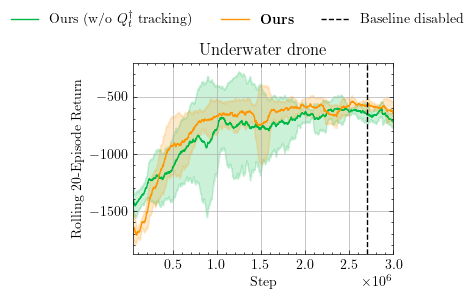

In [61]:
# Underwater drone ablation: episodic return
episodic_return_base = select_metrics(base_data, "charts/episodic_return")
episodic_return_ablation = select_metrics(ablation_data, "charts/episodic_return")

base_mean, base_std = rolling_stats(episodic_return_base.copy(), 100, 1000)
abl_mean, abl_std = rolling_stats(episodic_return_ablation.copy(), 100, 1000)

fig, ax = plt.subplots(1, 1, figsize=(3.6, 3.0))

ax.plot(abl_mean.index, abl_mean, label="Ours (w/o $Q_t^{\dagger}$ tracking)", color=ABLATION_COLOR)
ax.fill_between(
    abl_mean.index, abl_mean - abl_std, abl_mean + abl_std, alpha=0.2, color=ABLATION_COLOR
)
ax.plot(base_mean.index, base_mean, label=r"\textbf{Ours}", color=OURS_COLOR)
ax.fill_between(
    base_mean.index, base_mean - base_std, base_mean + base_std, alpha=0.2, color=OURS_COLOR
)

ax.axvline(x=0.9 * 3_000_000, color="black", linestyle="--", label="Baseline disabled")
ax.set_xlim(50_000, 3_000_000)
ax.set_title("Underwater drone")
ax.set_xlabel("Step")
ax.set_ylabel("Rolling 20-Episode Return")
ax.grid()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig("../gfx/ablation_episode_return_drone.pdf")


<>:20: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3036294/3678813574.py:20: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(abl_mean.index, abl_mean, label="Ours (w/o $Q_t^{\dagger}$ tracking)", color=ABLATION_COLOR)


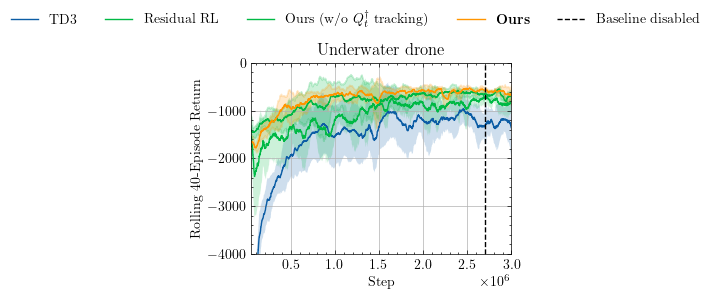

In [62]:
# Underwater drone ablation: episodic return
episodic_return_base = select_metrics(base_data, "charts/episodic_return")
episodic_return_ablation = select_metrics(ablation_data, "charts/episodic_return")
td3_data = pd.read_csv("expdata/td3.csv")
residual_data = pd.read_csv("expdata/residual_td3.csv")
episodic_return_td3 = select_metrics(td3_data, "charts/episodic_return")
episodic_return_residual = select_metrics(residual_data, "charts/episodic_return")

base_mean, base_std = rolling_stats(episodic_return_base.copy(), 50, 1000)
abl_mean, abl_std = rolling_stats(episodic_return_ablation.copy(), 50, 1000)
td3_mean, td3_std = rolling_stats(episodic_return_td3.copy(), 50, 1000)
res_mean, res_std = rolling_stats(episodic_return_residual.copy(), 40, 1000)

fig, ax = plt.subplots(1, 1, figsize=(3.6, 3.0))

ax.plot(td3_mean.index, td3_mean, label="TD3")
ax.fill_between(td3_mean.index, td3_mean - td3_std, td3_mean + td3_std, alpha=0.2)
ax.plot(res_mean.index, res_mean, label="Residual RL")
ax.fill_between(res_mean.index, res_mean - res_std, res_mean + res_std, alpha=0.2)
ax.plot(abl_mean.index, abl_mean, label="Ours (w/o $Q_t^{\dagger}$ tracking)", color=ABLATION_COLOR)
ax.fill_between(
    abl_mean.index, abl_mean - abl_std, abl_mean + abl_std, alpha=0.2, color=ABLATION_COLOR
)
ax.plot(base_mean.index, base_mean, label=r"\textbf{Ours}", color=OURS_COLOR)
ax.fill_between(
    base_mean.index, base_mean - base_std, base_mean + base_std, alpha=0.2, color=OURS_COLOR
)

ax.axvline(x=0.9 * 3_000_000, color="black", linestyle="--", label="Baseline disabled")
ax.set_xlim(50_000, 3_000_000)
ax.set_ylim(-4000, 0)
ax.set_title("Underwater drone")
ax.set_xlabel("Step")
ax.set_ylabel("Rolling 40-Episode Return")
ax.grid()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig("../gfx/ablation_episode_return_drone.pdf")


In [63]:
# Underwater drone rates after 2.7M steps
print("UNDERWATER GOAL REACHING RATE AFTER 2.7M STEPS (closer to 1 is better)")
base_goal = metrics_or_empty(base_data, "episode_stats/is_in_hole")
abl_goal = metrics_or_empty(ablation_data, "episode_stats/is_in_hole")
if base_goal is not None:
    print_metric_rate(base_goal, "OURS")
else:
    print("OURS")
    print("is_in_hole not found in base_data")
if abl_goal is not None:
    print_metric_rate(abl_goal, "OURS (w/o $Q_t^{\dagger}$ tracking)")
else:
    print("OURS (w/o $Q_t^{\dagger}$ tracking)")
    print("is_in_hole not found in ablation_data")

print("UNDERWATER HIGH COST REGION AVOIDANCE SCORE AFTER 2.7M STEPS (closer to 0 is better)")
base_avoid = metrics_or_empty(base_data, "episode_stats/avoidance_score")
abl_avoid = metrics_or_empty(ablation_data, "episode_stats/avoidance_score")
if base_avoid is not None:
    print_metric_rate(base_avoid, "OURS")
else:
    print("OURS")
    print("avoidance_score not found in base_data")
if abl_avoid is not None:
    print_metric_rate(abl_avoid, "OURS (w/o $Q_t^{\dagger}$ tracking)")
else:
    print("OURS (w/o $Q_t^{\dagger}$ tracking)")
    print("avoidance_score not found in ablation_data")


UNDERWATER GOAL REACHING RATE AFTER 2.7M STEPS (closer to 1 is better)
OURS
0.985 +- 0.011180339887498959
OURS (w/o $Q_t^{\dagger}$ tracking)
0.977 +- 0.008366600265340763
UNDERWATER HIGH COST REGION AVOIDANCE SCORE AFTER 2.7M STEPS (closer to 0 is better)
OURS
0.025348078110184996 +- 0.008380450110766902
OURS (w/o $Q_t^{\dagger}$ tracking)
0.020879820637103832 +- 0.015332819078949414


<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:27: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:25: SyntaxWarning: invalid escape sequence '\d'
<>:27: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3036294/2348646124.py:11: SyntaxWarning: invalid escape sequence '\d'
  print_metric_rate(abl_goal, "OURS (w/o $Q_t^{\dagger}$ tracking)")
/tmp/ipykernel_3036294/2348646124.py:13: SyntaxWarning: invalid escape sequence '\d'
  print("OURS (w/o $Q_t^{\dagger}$ tracking)")
/tmp/ipykernel_3036294/2348646124.py:25: SyntaxWarning: invalid escape sequence '\d'
  print_metric_rate(abl_avoid, "OURS (w/o $Q_t^{\dagger}$ tracking)")
/tmp/ipykernel_3036294/2348646124.py:27: SyntaxWarning: invalid escape sequence '\d'
  print("OURS (w/o $Q_t^{\dagger}$ tracking)")


<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3036294/704480283.py:13: SyntaxWarning: invalid escape sequence '\d'
  abl_label = "Ours (w/o $Q_t^{\dagger}$ tracking)" if add_labels else "_nolegend_"


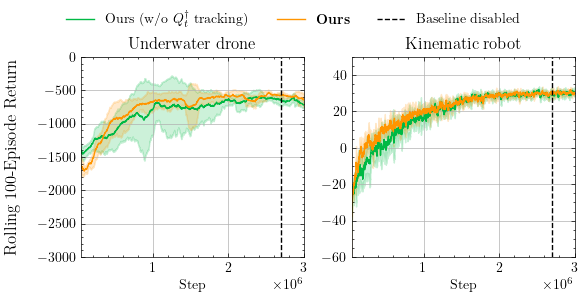

In [67]:
robot_ablation_data = pd.read_csv("expdata/ablation_q_robot.csv")
robot_base_data = pd.read_csv("expdata/robot_calfq.csv")
drone_ablation_data = pd.read_csv("expdata/drone_ablation.csv")
drone_base_data = pd.read_csv("expdata/drone_calf_no_selective_buffer.csv")


def episodic_return_band(df, rolling_window=20, grid_step=1000):
    episodic = select_metrics(df, "charts/episodic_return")
    return rolling_stats(episodic.copy(), rolling_window, grid_step)


def draw_ablation_return(ax, title, base_mean, base_std, abl_mean, abl_std, add_labels=False):
    abl_label = "Ours (w/o $Q_t^{\dagger}$ tracking)" if add_labels else "_nolegend_"
    ours_label = r"\textbf{Ours}" if add_labels else "_nolegend_"
    baseline_label = "Baseline disabled" if add_labels else "_nolegend_"

    ax.plot(abl_mean.index, abl_mean, label=abl_label, color=ABLATION_COLOR)
    ax.fill_between(
        abl_mean.index,
        abl_mean - abl_std,
        abl_mean + abl_std,
        alpha=0.2,
        color=ABLATION_COLOR,
    )

    ax.plot(base_mean.index, base_mean, label=ours_label, color=OURS_COLOR)
    ax.fill_between(
        base_mean.index,
        base_mean - base_std,
        base_mean + base_std,
        alpha=0.2,
        color=OURS_COLOR,
    )

    ax.axvline(x=0.9 * 3_000_000, color="black", linestyle="--", label=baseline_label)
    ax.set_xlim(50_000, 3_000_000)
    ax.set_title(title)
    ax.set_xlabel("Step")
    ax.grid()


drone_base_mean, drone_base_std = episodic_return_band(drone_base_data, 100, 1000)
drone_abl_mean, drone_abl_std = episodic_return_band(drone_ablation_data, 100, 1000)
robot_base_mean, robot_base_std = episodic_return_band(robot_base_data, 100, 1000)
robot_abl_mean, robot_abl_std = episodic_return_band(robot_ablation_data, 100, 1000)

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(6, 3.0))

draw_ablation_return(
    ax_left,
    "Underwater drone",
    drone_base_mean,
    drone_base_std,
    drone_abl_mean,
    drone_abl_std,
    add_labels=True,
)
draw_ablation_return(
    ax_right,
    "Kinematic robot",
    robot_base_mean,
    robot_base_std,
    robot_abl_mean,
    robot_abl_std,
)

ax_left.set_xlim(45_000, 3_000_000)
ax_left.set_ylim(-3000, 0)
ax_right.set_xlim(50_000, 3_000_000)
ax_right.set_ylim(-60, 50)
fig.supylabel("Rolling 100-Episode Return")

handles, labels = ax_left.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.03))
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("../gfx/ablation_episode_return_drone_robot.pdf")
